# 02 - Modelagem: baseline, comparacao de modelos e importancia de features

Este notebook usa o pipeline de `src/house_prices/features.py`
(`build_pipeline`) - o MESMO codigo usado por `src/house_prices/train.py` e pela
API Flask. Isso garante que o que experimentamos aqui e exatamente o que vai para
producao (nada de reimplementar a logica de features "so para o notebook").

Se `data/processed/house_prices_processed.csv` nao existir, rode antes:
`python -m house_prices.data.clean`

In [1]:
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from house_prices.config import PROCESSED_DATA_PATH, RANDOM_STATE, TARGET_COLUMN
from house_prices.features import build_pipeline

df = pd.read_csv(PROCESSED_DATA_PATH)
print(df.shape)

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("treino:", X_train.shape, " teste:", X_test.shape)

(21435, 20)
treino: (17148, 19)  teste: (4287, 19)


## 1. Baseline: "chutar a media"

Antes de qualquer modelo "de verdade", precisamos de um piso de comparacao. Um
`DummyRegressor` que sempre preve a media do preco de treino representa o que
conseguiriamos SEM nenhuma feature - qualquer modelo real precisa superar isso por
uma margem clara, senao nao esta agregando valor.

In [2]:
def evaluate(model_name, pipeline, X_test, y_test):
    preds = pipeline.predict(X_test)
    return {
        "modelo": model_name,
        "mae": mean_absolute_error(y_test, preds),
        "rmse": mean_squared_error(y_test, preds) ** 0.5,
        "r2": r2_score(y_test, preds),
    }

results = []

baseline = build_pipeline(DummyRegressor(strategy="mean"))
baseline.fit(X_train, y_train)
results.append(evaluate("baseline (media)", baseline, X_test, y_test))
results[-1]

{'modelo': 'baseline (media)',
 'mae': 232021.96104650255,
 'rmse': 355123.5860027801,
 'r2': -3.2687649180074274e-05}

## 2. Regressao Linear (modelo simples e interpretavel)

In [3]:
linear = build_pipeline(LinearRegression())
linear.fit(X_train, y_train)
results.append(evaluate("regressao linear", linear, X_test, y_test))
results[-1]

{'modelo': 'regressao linear',
 'mae': 97337.39761286433,
 'rmse': 156849.202157896,
 'r2': 0.8049168369015893}

## 3. Random Forest (modelo escolhido para producao)

E o modelo usado em `src/house_prices/train.py`. Testamos aqui com os mesmos
hiperparametros do script de treino, para que a comparacao seja justa com o que
efetivamente vai para a API.

In [4]:
forest = build_pipeline(
    RandomForestRegressor(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
)
forest.fit(X_train, y_train)
results.append(evaluate("random forest", forest, X_test, y_test))
results[-1]

{'modelo': 'random forest',
 'mae': 70865.36734369237,
 'rmse': 124407.18019766289,
 'r2': 0.8772713226451676}

In [5]:
comparison = pd.DataFrame(results).set_index("modelo")
comparison = comparison.round({"mae": 0, "rmse": 0, "r2": 3})
comparison

,mae,rmse,r2
modelo,,,
baseline (media),232022.0,355124.0,-0.000
regressao linear,97337.0,156849.0,0.805
random forest,70865.0,124407.0,0.877


**Leitura da tabela:** o Random Forest reduz o MAE (erro medio absoluto, em R$)
para bem menos da metade do baseline, e explica (R²) a maior parte da variancia do
preco - muito acima da regressao linear. Isso confirma a escolha de
RandomForestRegressor como modelo de producao em `train.py`: a relacao entre
features e preco nao e puramente linear (ex.: efeitos de localizacao e interacoes
entre `grade`/`sqft_living` que uma reta nao captura bem), e uma floresta lida
melhor com isso sem exigir engenharia de features manual adicional (como termos de
interacao explicitos).

## 4. Quais features mais pesam na decisao do modelo?

In [6]:
# Nomes das colunas depois do ColumnTransformer (numeric + ordinal + onehot de zipcode)
preprocessor = forest.named_steps["preprocessing"]
feature_names = preprocessor.get_feature_names_out()

importances = pd.Series(
    forest.named_steps["model"].feature_importances_, index=feature_names
).sort_values(ascending=False)

importances.head(15)

numeric__sqft_living               0.340858
numeric__grade                     0.269449
numeric__lat                       0.164127
numeric__long                      0.069055
numeric__sqft_living15             0.030613
ordinal__waterfront                0.026311
numeric__sqft_above                0.014490
numeric__house_age                 0.014061
numeric__view                      0.011935
numeric__sqft_lot                  0.010953
numeric__sqft_lot15                0.010499
numeric__bathrooms                 0.006318
numeric__years_since_renovation    0.005657
onehot__zipcode_98004              0.005368
numeric__sqft_basement             0.003572
dtype: float64

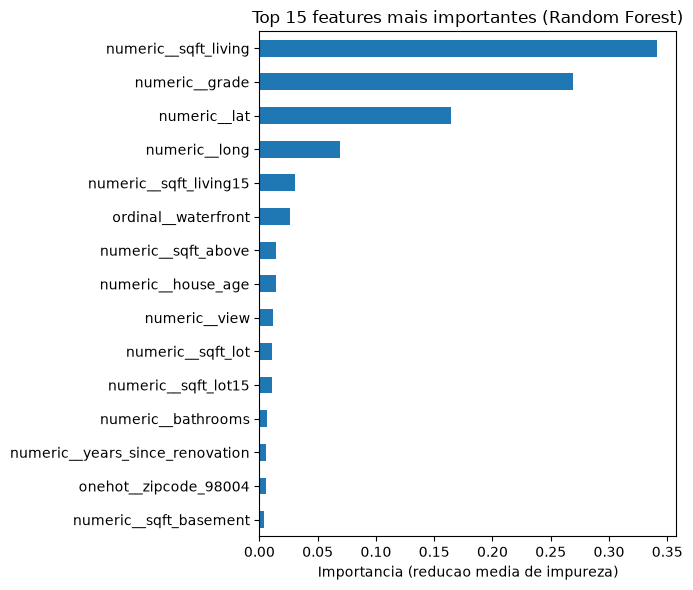

In [7]:
import matplotlib.pyplot as plt

importances.head(15).sort_values().plot.barh(figsize=(7, 6))
plt.title("Top 15 features mais importantes (Random Forest)")
plt.xlabel("Importancia (reducao media de impureza)")
plt.tight_layout()
plt.show()

`sqft_living`, `grade`, `lat`/`long` e o zipcode dominam - coerente com o que a
EDA (notebook 01) ja indicava visualmente (localizacao e area util/qualidade
explicam a maior parte do preco). Interessante notar que `house_age` e
`years_since_renovation` (features derivadas, criadas em
`add_engineered_features`) aparecem no ranking - validando que vale a pena
mante-las no pipeline em vez de usar `yr_built`/`yr_renovated` crus.

## 5. Conclusao e proximo passo

O pipeline treinado aqui e reproduzido de forma identica por
`python -m house_prices.train` (que roda no dataset completo, salva o modelo em
`models/model.joblib` e as metricas em `models/metrics.json`). Esse artefato e o
que a API Flask (`src/house_prices/api/app.py`) carrega para servir predicoes em
`/predict`.

Possiveis proximos passos (fora do escopo deste projeto de estudo, mas seriam o
passo natural depois): tuning de hiperparametros (GridSearchCV/Optuna), testar
Gradient Boosting, rastrear experimentos com MLflow e monitorar data drift em
producao - temas cobertos na Aula 08 do curso (`Fase1/aula08_...`).